In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import pre_cleaning
import Coincidences as coinc

In [3]:
def single_rate(timestamps_winter,timestamps_pti,timestamps_fern,base_dir,bin_width=300):
    #Plots the single telescope trigger rate of winter, fern, pti in one plot
    #Use
    fig,ax=plt.subplots(3,1,sharex=True,sharey=True)
    y,x=np.histogram(timestamps_winter,bins=np.arange(min(timestamps_winter),max(timestamps_winter)+bin_width+1,bin_width))
    time_rate=x[:-1]+bin_width/2
    rate=y/bin_width
    rate_av=round(np.mean(rate),2)
    time_rate_pd=pd.to_datetime(time_rate, unit='s', utc=True).tz_convert('UTC')
    ax[0].step(time_rate_pd,rate)
    ax[0].set_title("Winter, mean="+str(rate_av)+" Hz")
    ax[0].grid()
    #ax[0].set_ylabel("Trigger Rate [Hz]")
    y,x=np.histogram(timestamps_pti,bins=np.arange(min(timestamps_pti),max(timestamps_pti)+bin_width+1,bin_width))
    time_rate=x[:-1]+bin_width/2
    rate=y/bin_width
    rate_av=round(np.mean(rate),2)
    time_rate_pd=pd.to_datetime(time_rate, unit='s', utc=True).tz_convert('UTC')
    ax[1].step(time_rate_pd,rate,color="red")
    ax[1].set_title("PTI, mean="+str(rate_av)+" Hz")
    ax[1].grid()
    ax[1].set_ylabel("Trigger Rate [Hz]")
    y,x=np.histogram(timestamps_fern,bins=np.arange(min(timestamps_fern),max(timestamps_fern)+bin_width+1,bin_width))
    time_rate=x[:-1]+bin_width/2
    rate=y/bin_width
    rate_av=round(np.mean(rate),2)
    time_rate_pd=pd.to_datetime(time_rate, unit='s', utc=True).tz_convert('UTC')
    ax[2].step(time_rate_pd,rate,color="green")
    ax[2].set_title("Fern, mean="+str(rate_av)+" Hz")
    ax[2].grid()
    #ax[2].set_ylabel("Trigger Rate [Hz]")
    ax[2].set_xlabel("UT time")
    fig.suptitle(str(base_dir)+", Single Rates")
    path=f"{base_dir}/"
    name=f"{base_dir}"
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(path+name+"_single_rates.png",dpi=300)
    plt.show()

In [4]:
base_dir=Path("20260710_1959")
data_winter, timestamps_winter = coinc.load_telescope_tv("module_253", base_dir,rate_cut=20)
data_pti, timestamps_pti = coinc.load_telescope_tv("module_250", base_dir,rate_cut=100)
data_fern, timestamps_fern=coinc.load_telescope_tv("module_252", base_dir,rate_cut=100)

module_253: 1 files found
  -> 20260710_1959/start_2026-07-10T07-25-49Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  1377
Number of Events with package loss:  1377  ( 100.0 %)


ValueError: zero-size array to reduction operation minimum which has no identity

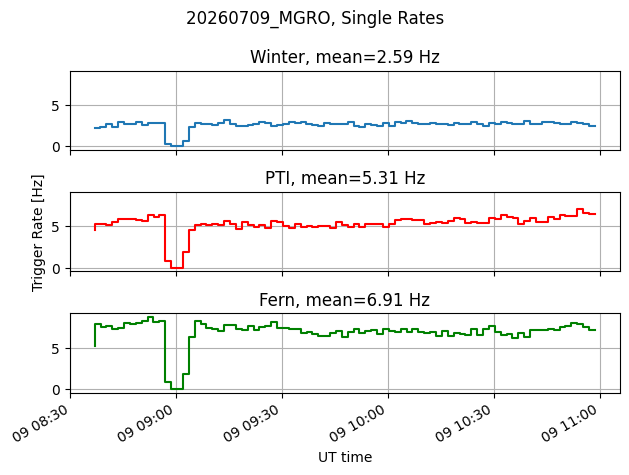

In [12]:
single_rate(timestamps_winter,timestamps_pti,timestamps_fern,base_dir,bin_width=100)

/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Offset: RMS=  0.00016 s, std= 0.00014 s
Corrected Offset: RMS=  0.0 s, std= 0.0 s


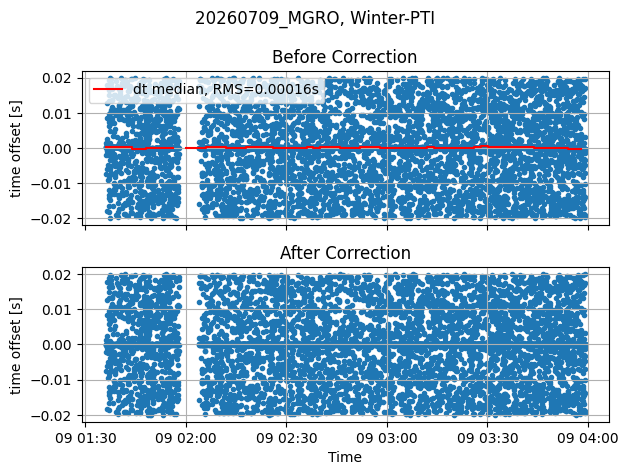

/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/yuriy/miniconda3/envs/py313/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Offset: RMS=  0.00015 s, std= 0.00015 s
Corrected Offset: RMS=  0.0 s, std= 0.0 s


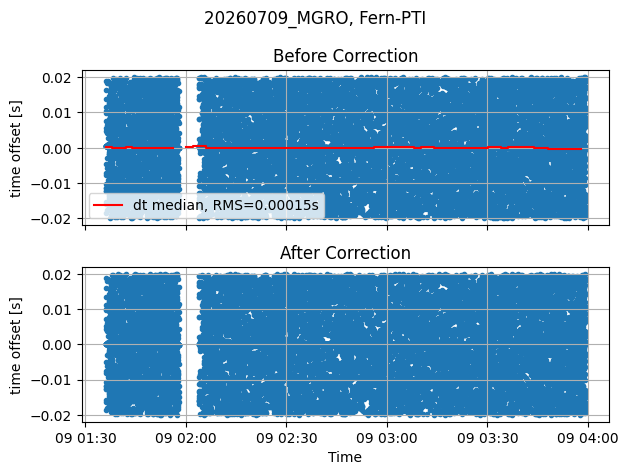

In [13]:
timestamps_winter_corr=coinc.correct_time(timestamps_winter,timestamps_pti,plot_name="Winter-PTI",base_dir=base_dir)
timestamps_fern_corr=coinc.correct_time(timestamps_fern,timestamps_pti,plot_name="Fern-PTI",base_dir=base_dir)

Number of events for telescope 1: 22309
Number of events for telescope 2: 45675
Number of coincident events within 0.001s: 3219 ( ~14.4% of all telescope 1 events and ~7.0% of all telescope 2 events.)


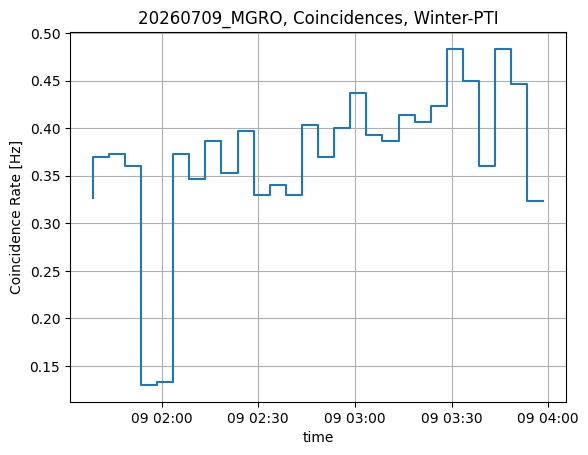

Number of events for telescope 1: 59433
Number of events for telescope 2: 45675
Number of coincident events within 0.001s: 5203 ( ~8.8% of all telescope 1 events and ~11.4% of all telescope 2 events.)


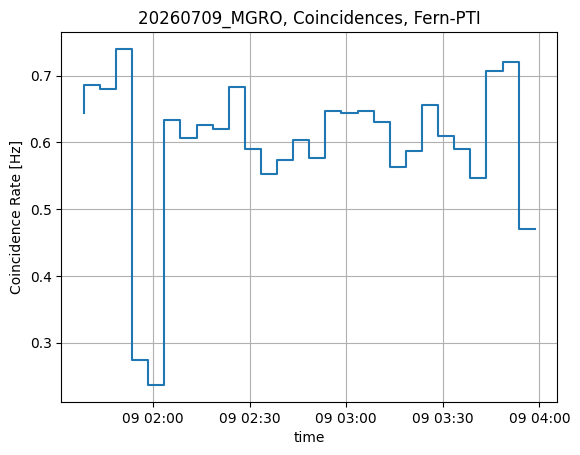

Number of events for telescope 1: 22309
Number of events for telescope 2: 59433
Number of coincident events within 0.001s: 4358 ( ~19.5% of all telescope 1 events and ~7.3% of all telescope 2 events.)


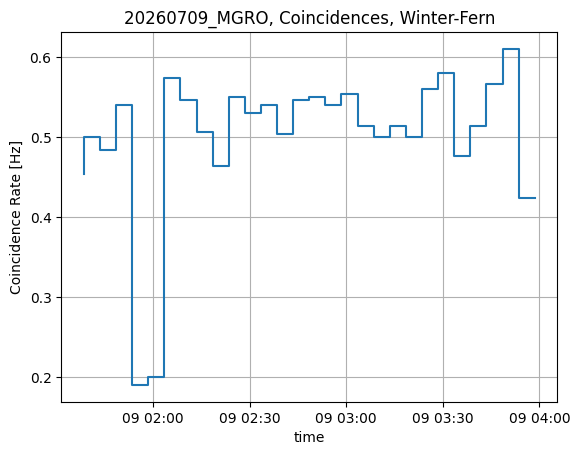

In [14]:
time_coinc_winter_pti, data_coinc_winter_pti,time_coinc_pti_winter,data_coinc_pti_winter=coinc.match_coinc(timestamps_winter_corr,data_winter,timestamps_pti,data_pti)
time_rate_winter_pti,rate_winter_pti=coinc.coinc_rate(time_coinc_winter_pti,"Winter-PTI",base_dir,bin_width=300)
time_coinc_fern_pti, data_coinc_fern_pti,time_coinc_pti_fern,data_coinc_pti_fern=coinc.match_coinc(timestamps_fern_corr,data_fern,timestamps_pti,data_pti)
time_rate_fern_pti,rate_fern_pti=coinc.coinc_rate(time_coinc_fern_pti,"Fern-PTI",base_dir,bin_width=300)
time_coinc_winter_fern, data_coinc_winter_fern,time_coinc_fern_winter,data_coinc_fern_winter=coinc.match_coinc(timestamps_winter_corr,data_winter,timestamps_fern_corr,data_fern)
time_rate_winter_fern,rate_winter_fern=coinc.coinc_rate(time_coinc_winter_fern,"Winter-Fern",base_dir,bin_width=300)

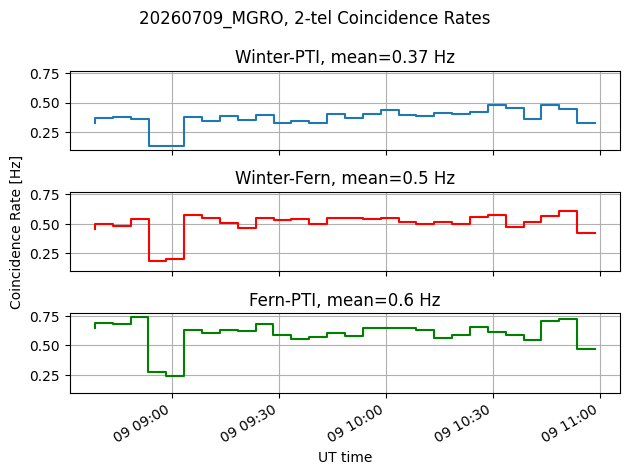

In [15]:
fig,ax=plt.subplots(3,1,sharex=True,sharey=True)
time_rate_pd=pd.to_datetime(time_rate_winter_pti, unit='s', utc=True).tz_convert('UTC')
rate=rate_winter_pti
rate_av=round(np.mean(rate),2)
ax[0].step(time_rate_pd,rate)
ax[0].set_title("Winter-PTI, mean="+str(rate_av)+" Hz")
ax[0].grid()
time_rate_pd=pd.to_datetime(time_rate_winter_fern, unit='s', utc=True).tz_convert('UTC')
rate=rate_winter_fern
rate_av=round(np.mean(rate),2)
ax[1].step(time_rate_pd,rate,color="red")
ax[1].set_title("Winter-Fern, mean="+str(rate_av)+" Hz")
ax[1].set_ylabel("Coincidence Rate [Hz]")
ax[1].grid()
time_rate_pd=pd.to_datetime(time_rate_fern_pti, unit='s', utc=True).tz_convert('UTC')
rate=rate_fern_pti
rate_av=round(np.mean(rate),2)
ax[2].step(time_rate_pd,rate,color="green")
ax[2].set_title("Fern-PTI, mean="+str(rate_av)+" Hz")
ax[2].grid()
ax[2].set_xlabel("UT time")
fig.suptitle(str(base_dir)+", 2-tel Coincidence Rates")
path=f"{base_dir}/"
name=f"{base_dir}"
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(path+name+"_2tel_coinc_rates.png",dpi=300)
plt.show()

Number of events T1: 22309
Number of events T2: 45675
Number of events T3: 59433
Number of triple coincidences within 0.001s: 2229 (~10.0% of T1, ~4.9% of T2, ~3.8% of T3)


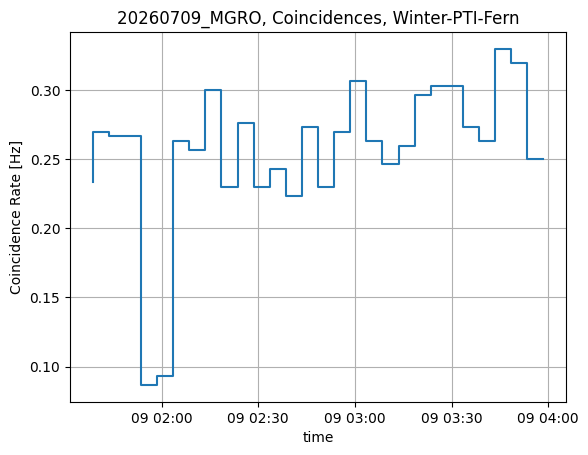

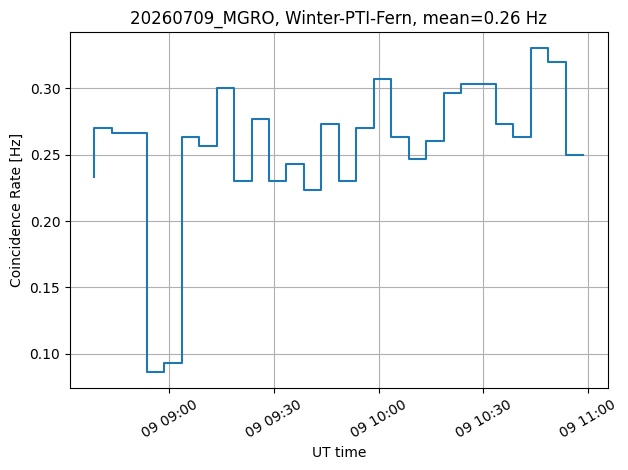

In [16]:
time_coinc3_winter,data_coinc3_winter,time_coinc3_pti,data_coinc3_pti,time_coinc3_fern,data_coinc3_fern=coinc.match_coinc3(timestamps_winter_corr,data_winter,timestamps_pti,data_pti,timestamps_fern_corr,data_fern)
time_rate_coinc3_winter,rate_coinc3_winter=coinc.coinc_rate(time_coinc3_winter,"Winter-PTI-Fern",base_dir,bin_width=300)

time_rate_pd=pd.to_datetime(time_rate_coinc3_winter, unit='s', utc=True).tz_convert('UTC')
rate=rate_coinc3_winter
rate_av=round(np.mean(rate),2)
plt.step(time_rate_pd,rate)
plt.grid()
plt.xlabel("UT time")
plt.ylabel("Coincidence Rate [Hz]")
plt.title(str(base_dir)+", Winter-PTI-Fern, mean="+str(rate_av)+" Hz")
plt.xticks(rotation=30)
path=f"{base_dir}/"
name=f"{base_dir}"
plt.tight_layout()
plt.savefig(path+name+"_3tel_coinc_rate.png",dpi=300)
plt.show()

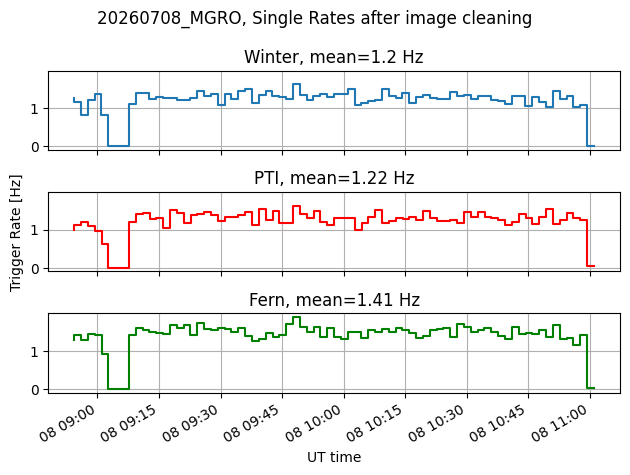

In [28]:
from make_pedestals import make_pedestal_images
from image_cleaning import threshold_clean
data_clean=data_winter
time=timestamps_winter
def image_clean(data,time):
    pedestal, pedestal_variance = make_pedestal_images(data)
    ped_subtracted_events = data - pedestal
    cleaned_events=[]
    cleaned_time=[]
    for i in range(len(ped_subtracted_events)):
        cleaned_event, mask = threshold_clean(ped_subtracted_events[i].reshape(32,32), pedestal_variance.reshape(32,32))
        if(np.sum(mask)>=3):
            cleaned_events.append(data[i])
            cleaned_time.append(time[i])
    return(np.asarray(cleaned_events),np.asarray(cleaned_time))

clean_time_winter=image_clean(data_winter,timestamps_winter)[1]
clean_time_pti=image_clean(data_pti,timestamps_pti)[1]
clean_time_fern=image_clean(data_fern,timestamps_fern)[1]

single_rate(clean_time_winter,clean_time_pti,clean_time_fern,base_dir,bin_width=100)

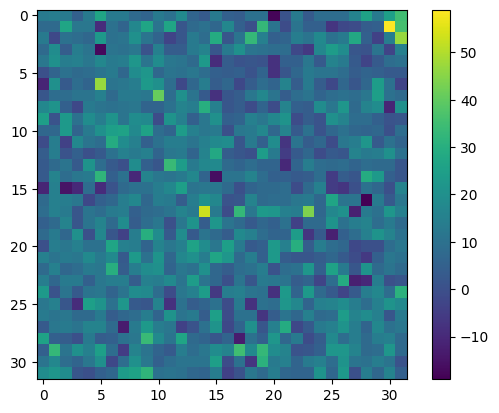

In [32]:
data_winter=image_clean(data_winter,timestamps_winter)[0]
plt.imshow(data_winter[100].reshape(32,32))
plt.colorbar()

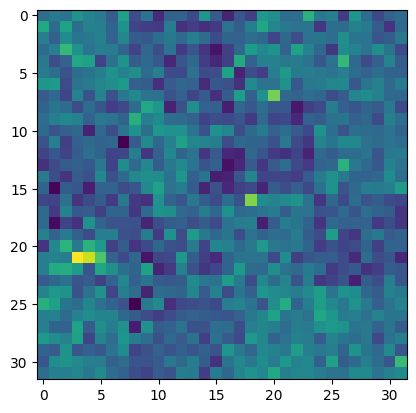

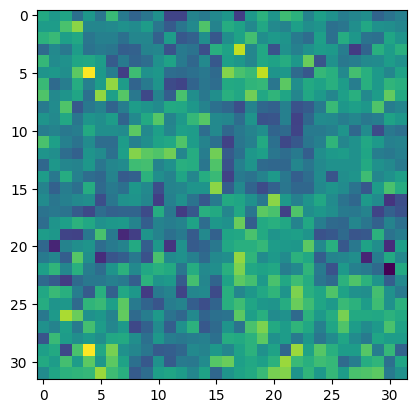

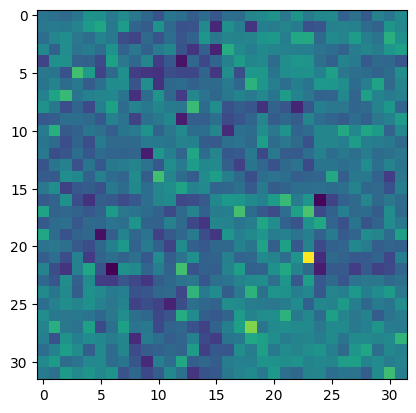

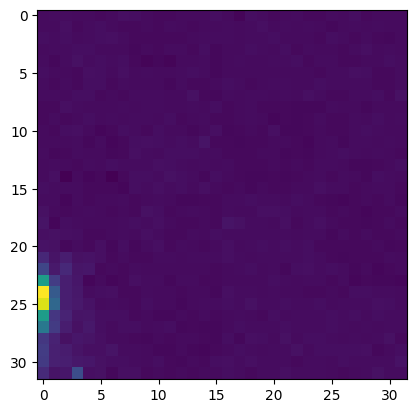

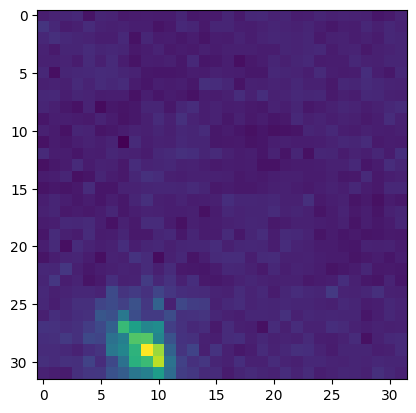

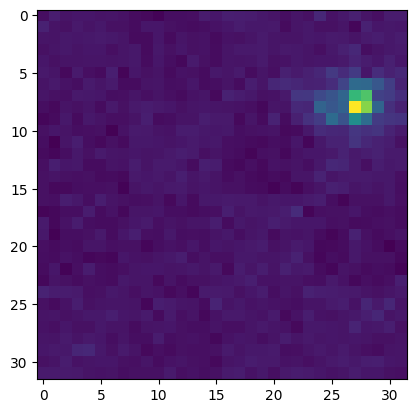

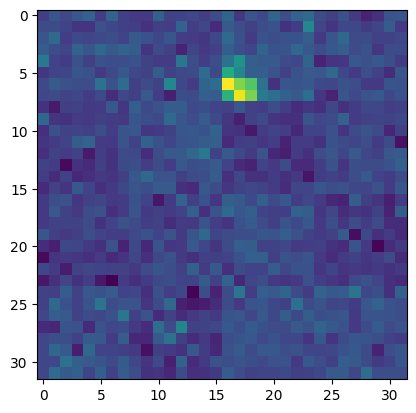

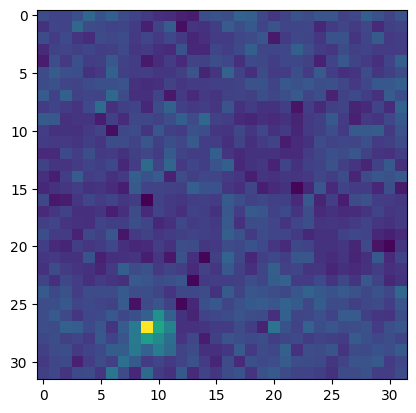

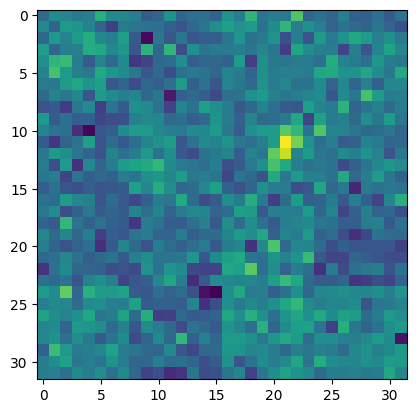

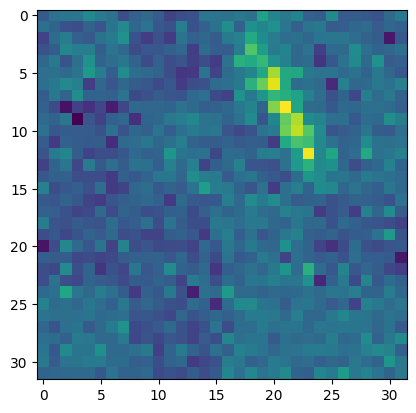

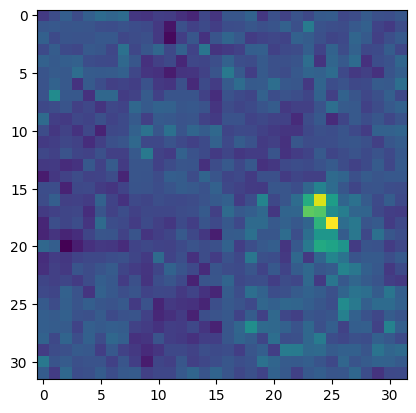

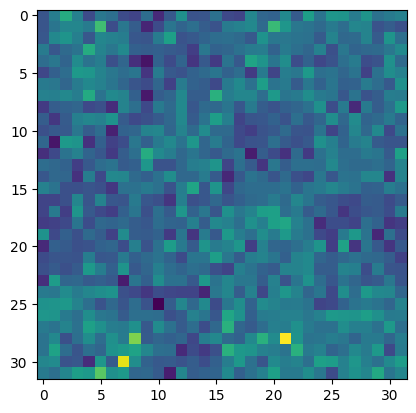

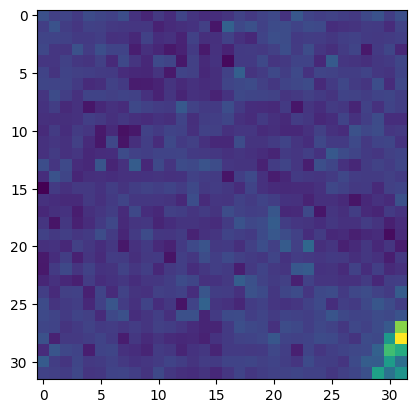

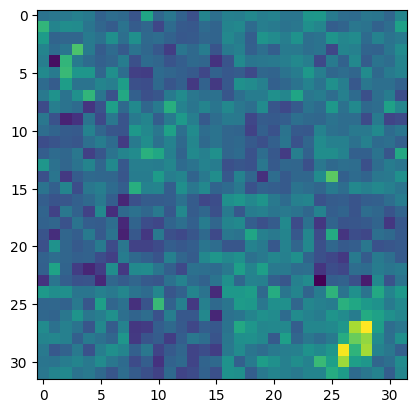

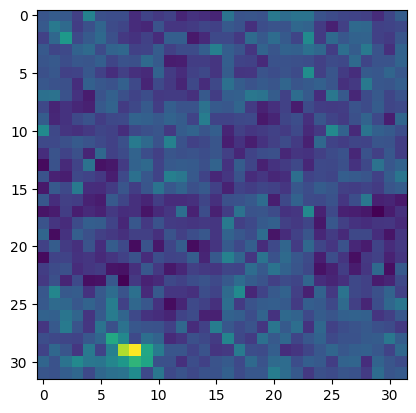

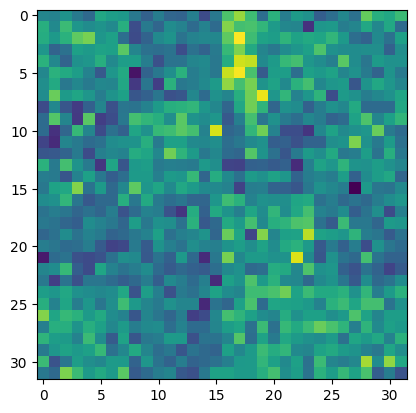

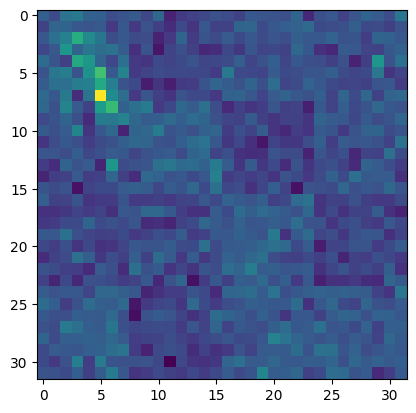

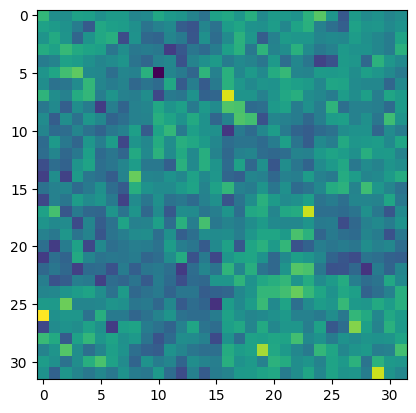

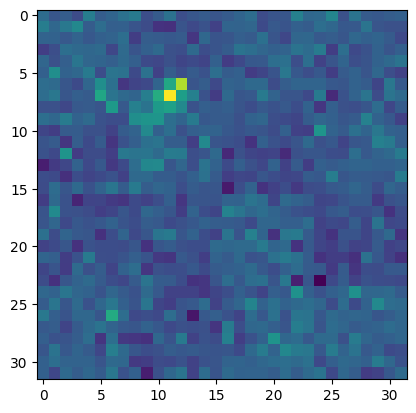

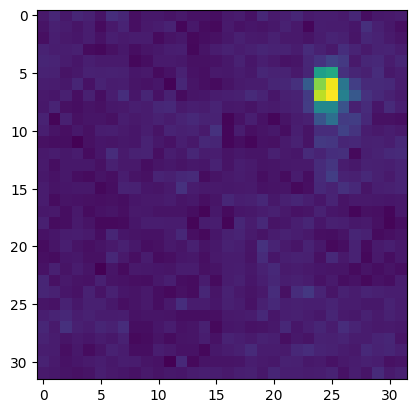

In [38]:
for i in range(20):
    plt.imshow(data_coinc_winter_fern[i*100].reshape(32,32))
    plt.show()